In [ ]:
from astropy.table import Table
from glob import glob
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import pandas as pd
import polars as pl
import sys
import torch

CPU times: user 3 μs, sys: 1 μs, total: 4 μs
Wall time: 8.82 μs


In [ ]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [2]:
tt = np.linspace(54884.5, 63111.5, 128)
periods = np.arange(1, 30, 0.2275)

ff = 1/periods
fmin = np.min(ff)
fmax = np.max(ff)
tmingr = np.min(tt)
tmaxgr = np.max(tt)

In [23]:
def accuracy(frac_err, threshold=0.1):
    return sum(frac_err <= threshold) / len(frac_err)

In [ ]:
sim_input = "/testing_csvs_section5/simulation_input_30_log6.csv"
cnn_periods = pd.read_csv(sim_input, header=0, index_col="simulation_number").sort_index()
cnn_periods = cnn_periods.rename(columns={'period':'true_period'})
cnn_periods.index.names = ['sim_id']

cnn_periods_test = cnn_periods[900000:]

In [ ]:
predictionspath = "files/testing_csvs_section5/6_clump_nor_norm_nan_all/asassn_clump_0_predictions.csv"
final = pd.read_csv(predictionspath, header=0).sort_index()
final['sim_id'] = final.index
idswithperiods = final.join(cnn_periods_test, on='sim_id', how="inner", lsuffix='valid2', rsuffix='test')
d2 = idswithperiods.eval("frac = sigma/period").query("period > 0")
d2['frac_err'] = abs(d2['period'] - d2['true_period'])/d2['true_period']

In [67]:
def plotter_scatter(datatable):
    tixs2 = [0, 5, 10, 15, 20, 25, 30]
    frac_err = datatable['frac_err']
    frac_err2 = datatable.query("sigma<3")['frac_err']
    fig, axs = plt.subplots(2, 1, figsize=(9, 14), layout='constrained')

    im1 = axs[0].hexbin("true_period", "period",  data=datatable, mincnt=1, vmax=50, rasterized=True)
    axs[0].plot([0, 30], [0, 30], "k--", label="1:1")
    axs[0].plot([0, 30*0.9], [0, 30], "r:",  label="90th percentile")
    axs[0].plot([0, 30], [0, 30*0.9], "r:",  label="90th percentile")
    axs[0].set(xlim=(0, 30), ylim=(0, 30))
    axs[0].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[0].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[0].set(xlabel='True Period (days)', ylabel='Predicted Period (days)')
    axs[0].set_title(f'{100*accuracy(frac_err, 0.1):.0f}% within 10%, {100*accuracy(frac_err, 0.2):.0f}% within 20%', weight='bold')
    fig.colorbar(im1, pad=0, label='Number', extend='max')

    im2 = axs[1].hexbin("true_period", "period", data=datatable.query("sigma<3"), mincnt=1, vmax=15, rasterized=True)
    axs[1].plot([0, 30], [0, 30], "k--", label="1:1")
    axs[1].plot([0, 30*0.9], [0, 30], "r:",  label="90th percentile")
    axs[1].plot([0, 30], [0, 30*0.9], "r:",  label="90th percentile")
    axs[1].set(xlabel='True Period (days)', ylabel='Predicted Period (days)')    
    axs[1].set_title(f'{100*accuracy(frac_err2, 0.1):.0f}% within 10%, {100*accuracy(frac_err2, 0.2):.0f}% within 20%', weight='bold')
    axs[1].set(xlim=(0, 30), ylim=(0, 30))
    axs[1].set_yticks(ticks = tixs2, labels=tixs2, weight='bold')
    axs[1].set_xticks(ticks = tixs2, labels=tixs2, weight='bold')
    
    fig.colorbar(im2, pad=0, label='Number', extend='max')
    plt.savefig('truepred.pdf', dpi=300)
    plt.show()

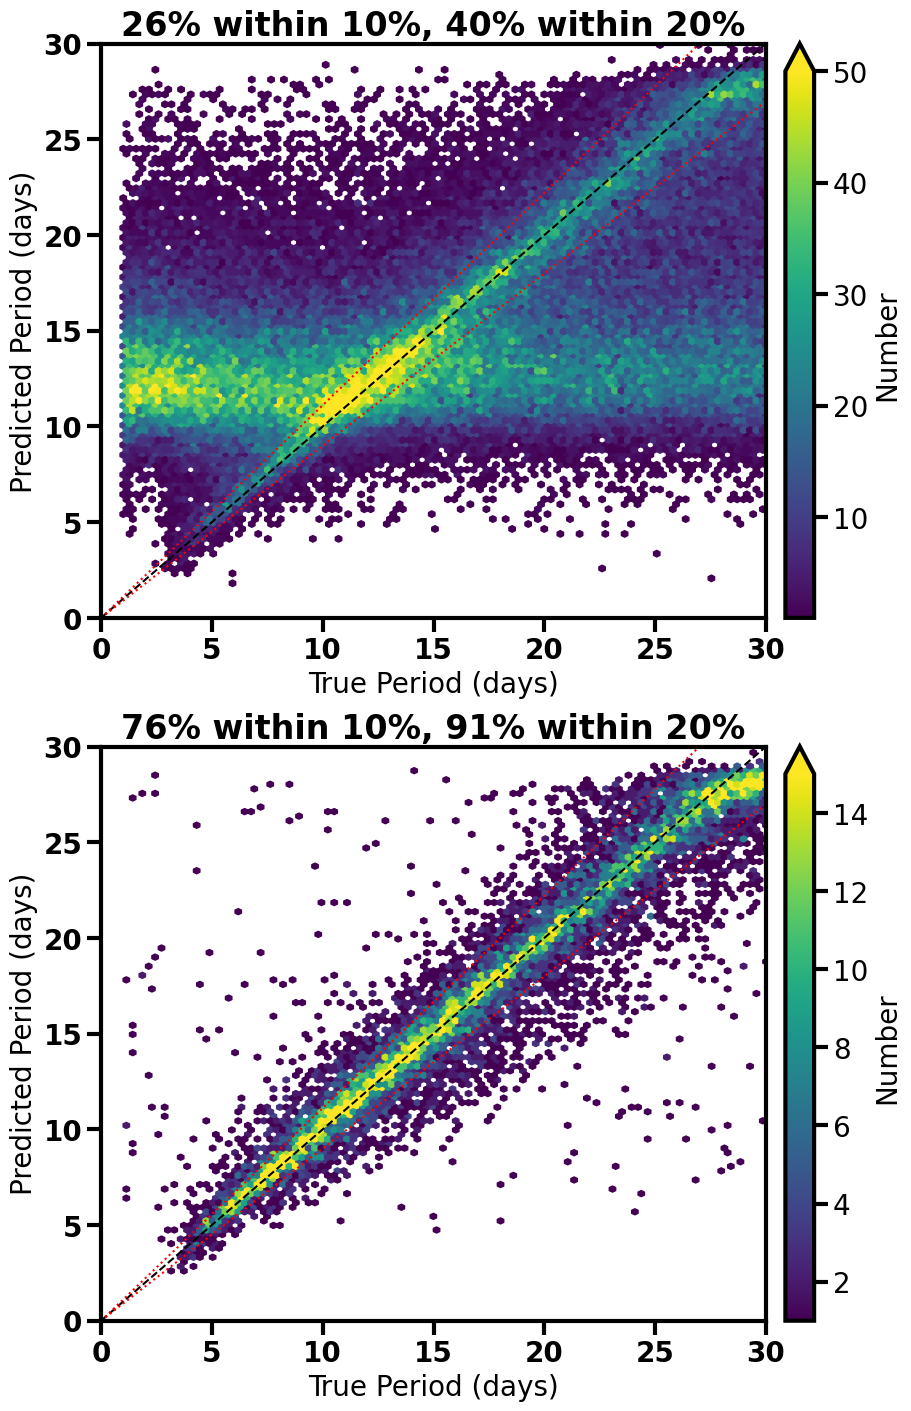

In [68]:
plotter_scatter(d2)